# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fuzzylite as fl
from fuzzylite import settings
# Register custom hedges to match lecture slide definitions
settings.factory_manager.hedge.constructors["slightly"] = lambda: fl.HedgeLambda("slightly", lambda x: x ** 1.7)
settings.factory_manager.hedge.constructors["more_or_less"] = lambda: fl.HedgeLambda("more_or_less", lambda x: x ** 0.5)
settings.factory_manager.hedge.constructors["a_little"] = lambda: fl.HedgeLambda("a_little", lambda x: x ** 1.3)
settings.factory_manager.hedge.constructors["extremely"] = lambda: fl.HedgeLambda("extremely", lambda x: x ** 3)
settings.factory_manager.hedge.constructors["very_very"] = lambda: fl.HedgeLambda("very_very", lambda x: x ** 4)
print(f"pyfuzzylite version: {fl.__version__}")
print(f"Available hedges: {list(settings.factory_manager.hedge.constructors.keys())}")

pyfuzzylite version: 8.0.6
Available hedges: ['any', 'extremely', 'not', 'seldom', 'somewhat', 'very', 'slightly', 'more_or_less', 'a_little', 'very_very']


# Plotting Helpers

In [4]:
def get_output(engine, name):
    """Extract a scalar float from a fuzzy engine output variable.

    pyfuzzylite may return a numpy array instead of a plain float.
    This helper handles both cases safely.
    """
    val = engine.output_variable(name).value
    return float(val.item()) if hasattr(val, 'item') else float(val)


def plot_membership_functions(variable, title=None, ax=None):
    """Plot all membership functions for a pyfuzzylite variable."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3.5))
    x = np.linspace(variable.minimum, variable.maximum, 500)
    for term in variable.terms:
        y = np.array([float(term.membership(xi)) for xi in x])
        ax.plot(x, y, linewidth=2, label=term.name)
    ax.set_xlabel(variable.name)
    ax.set_ylabel('Membership Degree')
    ax.set_title(title or f'Membership Functions: {variable.name}')
    ax.legend(loc='best', fontsize=9)
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)
    return ax


def plot_simulation(times, speeds, throttles, errors, target, title="Cruise Control Response"):
    """Plot a 3-panel time-domain response for a control simulation."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(times, speeds, 'b-', linewidth=1.5, label='Actual Speed')
    axes[0].axhline(y=target, color='r', linestyle='--', linewidth=1, label=f'Target ({target} km/h)')
    axes[0].set_ylabel('Speed (km/h)')
    axes[0].legend(loc='best')
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(times, throttles, 'g-', linewidth=1.5)
    axes[1].axhline(y=0, color='gray', linestyle=':', linewidth=0.5)
    axes[1].set_ylabel('Throttle')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(times, errors, 'r-', linewidth=1.5)
    axes[2].axhline(y=0, color='gray', linestyle=':', linewidth=0.5)
    axes[2].set_ylabel('Speed Error (km/h)')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_comparison(times, speed_dict, target, title="Controller Comparison"):
    """Overlay multiple speed traces for comparison."""
    plt.figure(figsize=(10, 5))
    for label, speeds in speed_dict.items():
        plt.plot(times, speeds, linewidth=1.5, label=label)
    plt.axhline(y=target, color='r', linestyle='--', linewidth=1, label=f'Target ({target} km/h)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Speed (km/h)')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_control_surface(engine, input1_name, input2_name, output_name, resolution=50):
    """Generate and plot the 3D control surface for a 2-input, 1-output fuzzy system."""
    iv1 = engine.input_variable(input1_name)
    iv2 = engine.input_variable(input2_name)

    x1 = np.linspace(iv1.minimum, iv1.maximum, resolution)
    x2 = np.linspace(iv2.minimum, iv2.maximum, resolution)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)

    for i in range(len(x2)):
        for j in range(len(x1)):
            iv1.value = float(x1[j])
            iv2.value = float(x2[i])
            engine.process()
            Z[i, j] = get_output(engine, output_name)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X1, X2, Z, cmap='RdYlGn', edgecolor='none', alpha=0.85)
    ax.set_xlabel(input1_name)
    ax.set_ylabel(input2_name)
    ax.set_zlabel(output_name)
    ax.set_title(f'Control Surface: {engine.name}')
    fig.colorbar(surf, shrink=0.5, aspect=10, label=output_name)
    plt.tight_layout()
    plt.show()
    return X1, X2, Z


print("Plotting helpers loaded.")

Plotting helpers loaded.


# Exercise 1
# Task 1.1

In [5]:
class CarPlant:
 """Simple car dynamics for cruise control simulation."""
 def __init__(self, mass=1200, drag_coeff=0.3, force_gain=30, dt=0.1):
    self.mass = mass # kg
    self.drag_coeff = drag_coeff # aerodynamic drag coefficient
    self.force_gain = force_gain # Newtons per unit of throttle output
    self.dt = dt # simulation time step (seconds)
    self.speed = 0.0 # current speed in km/h
    self.prev_speed = 0.0 # previous speed (for acceleration calc)
 def reset(self, initial_speed):
    """Reset the plant to a given initial speed."""
    self.speed = initial_speed
    self.prev_speed = initial_speed
 def step(self, throttle, disturbance=0.0):
    """
    Advance one time step.
    Parameters
    ----------
    throttle : float
    Controller output (can be negative for braking).
    disturbance : float
    External force in Newtons (e.g. hill gravity, headwind).
    Returns
    -------
    speed : float
    Updated speed in km/h.
    """
    self.prev_speed = self.speed
    # Compute throttle force
    throttle_force = throttle * self.force_gain
    # TODO: Compute speed in m/s (divide km/h by 3.6)
    speed_ms = self.speed / 3.6
    
    # Compute drag force
    drag_force = self.drag_coeff * speed_ms ** 2
    # TODO: Compute net force and acceleration
    net_force = throttle_force - drag_force + disturbance
    
    # TODO: Compute acceleration
    acceleration_ms2 = net_force / self.mass
    
    speed_change_kmh = acceleration_ms2 * self.dt * 3.6 # convert m/s² back to km/h change
    self.speed = max(0.0, self.speed + speed_change_kmh)
    return self.speed
 def get_acceleration(self):
    """Return acceleration in km/h per second."""
    return (self.speed - self.prev_speed) / self.dt

# Task 1.2

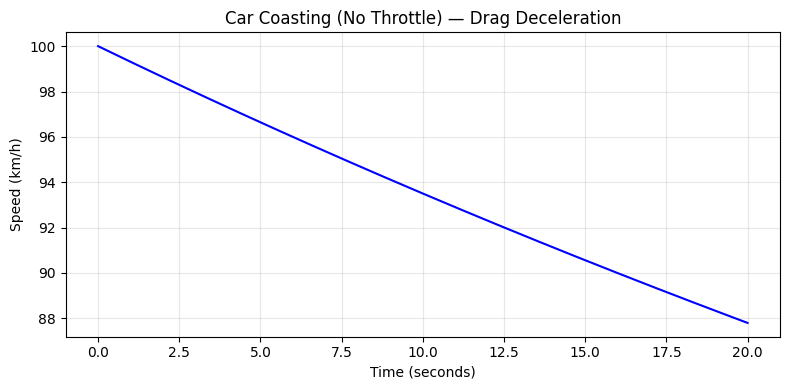

Speed after 20s: 87.80 km/h


In [7]:
# TODO: Create a CarPlant object called "plant"
plant = CarPlant()
# TODO: reset the plant to 100 km/h
plant.reset(initial_speed=100.0)
times_coast = [0.0]
speeds_coast = [100.0]
for step in range(1, 201):
    t = step * plant.dt
    speed = plant.step(throttle=0.0)
    # Recording time and speed over simulation
    times_coast.append(t)
    speeds_coast.append(speed)
plt.figure(figsize=(8, 4))
plt.plot(times_coast, speeds_coast, 'b-', linewidth=1.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (km/h)')
plt.title('Car Coasting (No Throttle) — Drag Deceleration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Speed after 20s: {speeds_coast[-1]:.2f} km/h")

# Exercise 2
# Task 2.1

In [8]:
def create_mamdani_cruise_controller():
    """Create a Mamdani fuzzy cruise controller."""
    engine = fl.Engine(
        name="CruiseControl_Mamdani",
        input_variables=[
            fl.InputVariable(
                name="speed_error", minimum=-30, maximum=30,
                terms=[
                    fl.Trapezoid("large_negative", -30, -30, -15, -5),
                    fl.Triangle("small_negative", -10, -5, 0),
                    fl.Triangle("zero", -5, 0, 5),
                    fl.Triangle("small_positive", 0, 5, 10),
                    fl.Trapezoid("large_positive", 5, 15, 30, 30),
                ],
            ),
            fl.InputVariable(
                name="acceleration", minimum=-5, maximum=5,
                terms=[
                    fl.Trapezoid("braking", -5, -5, -2, 0),
                    fl.Triangle("steady", -1, 0, 1),
                    fl.Trapezoid("accelerating", 0, 2, 5, 5),
                ],
            ),
        ],
        output_variables=[
            fl.OutputVariable(
                name="throttle", minimum=-50, maximum=50,
                aggregation=fl.Maximum(),
                defuzzifier=fl.Centroid(200),
                terms=[
                    fl.Trapezoid("brake_hard", -50, -50, -30, -10),
                    fl.Triangle("brake_light", -20, -10, 0),
                    fl.Triangle("maintain", -5, 0, 5),
                    fl.Triangle("accelerate_light", 0, 10, 20),
                    fl.Trapezoid("accelerate_hard", 10, 30, 50, 50),
                ],
            ),
        ],
        rule_blocks=[
            fl.RuleBlock(
                name="rules",
                conjunction=fl.Minimum(),
                disjunction=fl.Maximum(),
                implication=fl.Minimum(),
                activation=fl.General(),
                rules=[
                    fl.Rule.create("if speed_error is large_negative then throttle is brake_hard"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is accelerating then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is steady then throttle is brake_light"),
                    fl.Rule.create("if speed_error is small_negative and acceleration is braking then throttle is maintain"),
                    fl.Rule.create("if speed_error is zero then throttle is maintain"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is braking then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is steady then throttle is accelerate_light"),
                    fl.Rule.create("if speed_error is small_positive and acceleration is accelerating then throttle is maintain"),
                    fl.Rule.create("if speed_error is large_positive then throttle is accelerate_hard"),
                ],
            ),
        ],
    )
    return engine


mamdani = create_mamdani_cruise_controller()
print(f"Engine: {mamdani.name}, Rules: {len(mamdani.rule_blocks[0].rules)}")

Engine: CruiseControl_Mamdani, Rules: 9


# Task 2.2

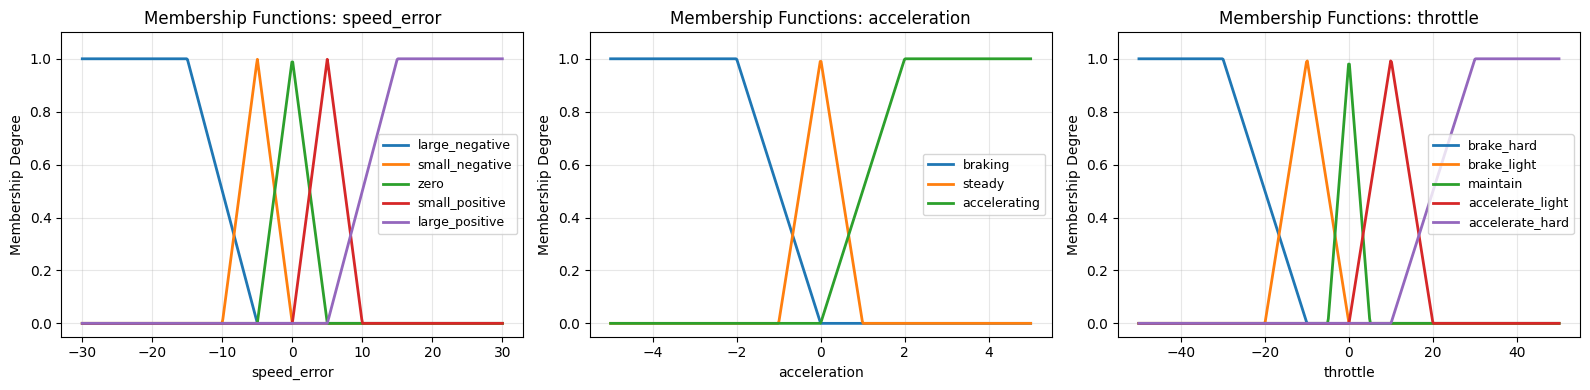

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_membership_functions(mamdani.input_variable("speed_error"), ax=axes[0])
plot_membership_functions(mamdani.input_variable("acceleration"), ax=axes[1])
plot_membership_functions(mamdani.output_variable("throttle"), ax=axes[2])
plt.tight_layout()
plt.show()


# Task 2.3

In [10]:
test_cases = [
 (20.0, 0.0, "Too slow, steady"),
 (-15.0, 2.0, "Too fast, still accelerating"),
 (3.0, -1.0, "Slightly slow, decelerating"),
 (0.0, 0.0, "On target, steady"),
]
print(f"{'Description':<35} {'Error':>6} {'Accel':>6} {'Throttle':>10}")
print("-" * 62)
for err, acc, desc in test_cases:
 mamdani.input_variable("speed_error").value = err
 mamdani.input_variable("acceleration").value = acc
 mamdani.process()
 throttle = get_output(mamdani, "throttle")
 print(f"{desc:<35} {err:>6.1f} {acc:>6.1f} {throttle:>10.2f}")

Description                          Error  Accel   Throttle
--------------------------------------------------------------
Too slow, steady                      20.0    0.0      34.44
Too fast, still accelerating         -15.0    2.0     -34.44
Slightly slow, decelerating            3.0   -1.0       7.37
On target, steady                      0.0    0.0       0.00


# Exercise 3
# Task 3.1

In [11]:
def run_simulation(engine, plant, target_speed, initial_speed, n_steps=500, disturbance_fn=None):
    """
    Run a closed-loop fuzzy control simulation.
    Parameters
    ----------
    engine : fl.Engine
    The fuzzy inference engine (controller).
    plant : CarPlant
    The plant model.
    target_speed : float
    Desired speed in km/h.
    initial_speed : float
    Starting speed in km/h.
    n_steps : int
    Number of simulation steps.
    disturbance_fn : callable or None
    A function f(t) -> force (Newtons) for external disturbances.
    Returns
    -------
    dict with keys: 'times', 'speeds', 'throttles', 'errors'
    """
    plant.reset(initial_speed)
    times = [0.0]
    speeds = [initial_speed]
    throttles = [0.0]
    errors = [target_speed - initial_speed]

    for step in range(1, n_steps + 1):
        t = step * plant.dt
        speed_error = target_speed - plant.speed
        acceleration = plant.get_acceleration()
        se_clamped = np.clip(speed_error, -30, 30)
        ac_clamped = np.clip(acceleration, -5, 5)
        engine.input_variable("speed_error").value = float(se_clamped)
        engine.input_variable("acceleration").value = float(ac_clamped)
        engine.process()
        throttle = get_output(engine, "throttle")
        dist = disturbance_fn(t) if disturbance_fn else 0.0
        new_speed = plant.step(throttle, disturbance=dist)
        times.append(t)
        speeds.append(new_speed)
        throttles.append(throttle)
        errors.append(target_speed - new_speed)
    return {'times': times, 'speeds': speeds, 'throttles': throttles, 'errors': errors}

# Task 3.2

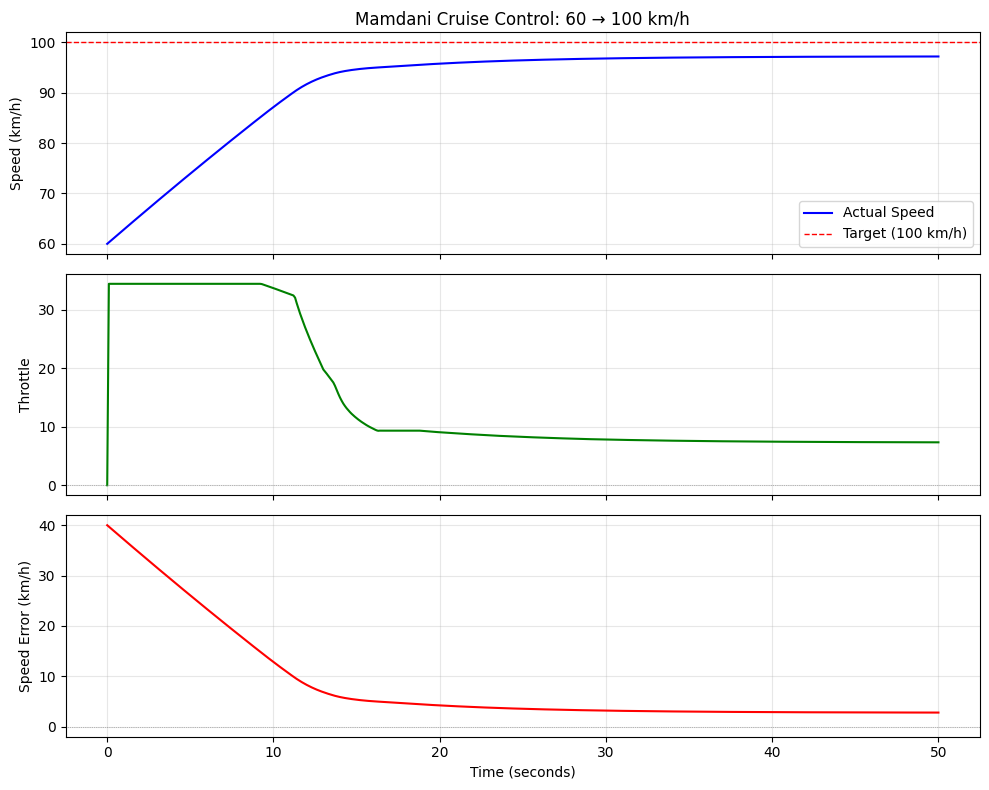

Final speed: 97.20 km/h
Steady-state error: 2.80 km/h
Max overshoot: -2.80 km/h


In [12]:
plant = CarPlant()
result = run_simulation(mamdani, plant, target_speed=100, initial_speed=60, n_steps=500)
plot_simulation(result['times'], result['speeds'], result['throttles'], result['errors'],
 target=100, title='Mamdani Cruise Control: 60 → 100 km/h')
# Performance metrics
final_speed = result['speeds'][-1]
steady_state_error = 100 - final_speed
max_speed = max(result['speeds'])
overshoot = max_speed - 100
print(f"Final speed: {final_speed:.2f} km/h")
print(f"Steady-state error: {steady_state_error:.2f} km/h")
print(f"Max overshoot: {overshoot:.2f} km/h")

# Task 3.3

# Exercise 4
# Task 4.1

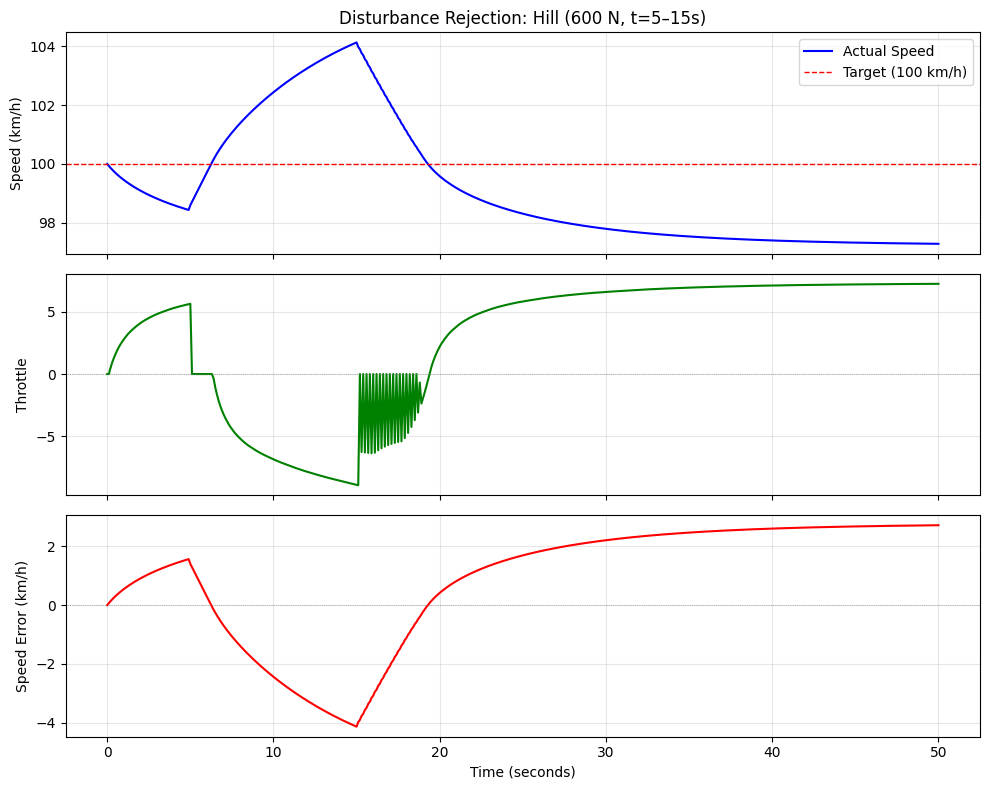

Minimum speed during hill: 97.29 km/h
Speed drop: 2.71 km/h
Final speed (after hill): 97.29 km/h


In [17]:
def hill_disturbance(t):
    """600 N opposing force between t=5 and t=15 seconds."""
    return 600.0 if 5 <= t <= 15 else 0.0
# TODO: Create and run the simulation according to the description in the markdown cell above
# passing "hill_disturbance" as the disturbance function
# Tip: See the "run_simulation" definition in Exercise 3.1 and an example of its use with
# only 5 arguments (note: here you will need 6 arguments)
result_hill = run_simulation(mamdani, plant, target_speed=100, initial_speed=100, n_steps=500, disturbance_fn=hill_disturbance)

plot_simulation(result_hill['times'], result_hill['speeds'], result_hill['throttles'],
    result_hill['errors'], target=100, title='Disturbance Rejection: Hill (600 N, t=5–15s)')

min_speed = min(result_hill['speeds'])
print(f"Minimum speed during hill: {min_speed:.2f} km/h")
print(f"Speed drop: {100 - min_speed:.2f} km/h")
print(f"Final speed (after hill): {result_hill['speeds'][-1]:.2f} km/h")


# Task 4.2

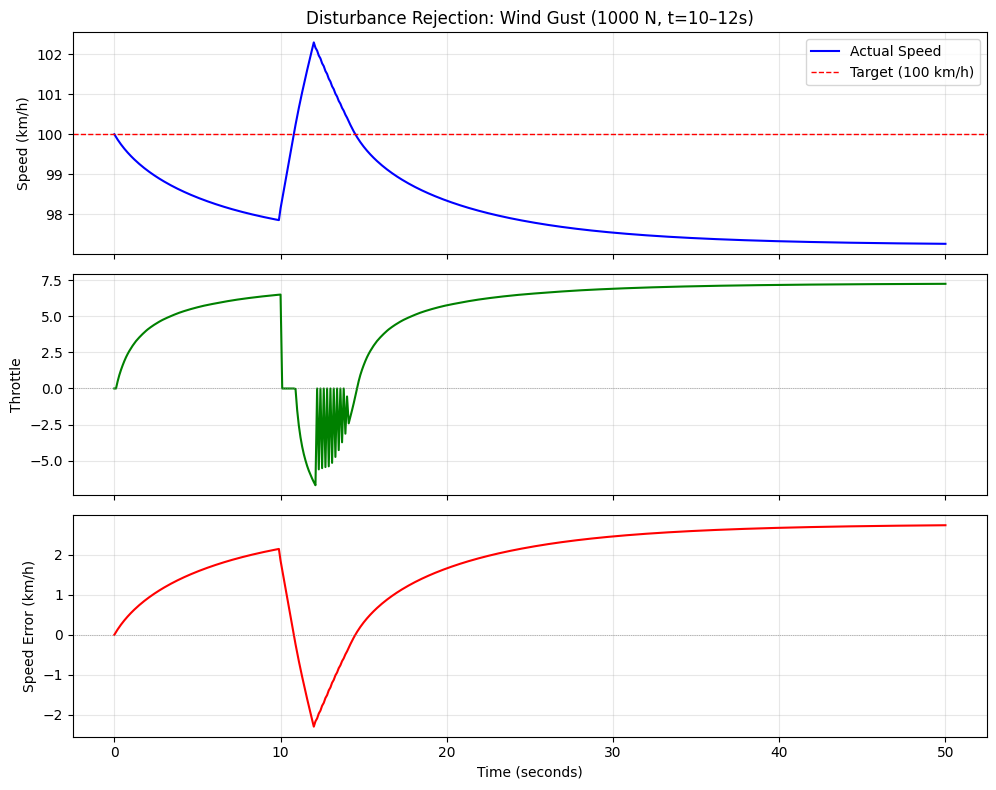

Minimum speed during gust: 97.26 km/h
Speed drop: 2.74 km/h


In [18]:
# Tip: See Exercise 4.1
# TODO: Define a wind gust disturbance function "wind_gust"
# applying 1000 N between t=10 and t=12
def wind_gust(t):
    return 1000.0 if 10 <= t <= 12 else 0.0
result_wind = run_simulation(mamdani, plant, target_speed=100, initial_speed=100, n_steps=500, disturbance_fn=wind_gust)
# TODO: Run the simulation from 100 km/h
# TODO: Plot the results
plot_simulation(result_wind['times'], result_wind['speeds'], result_wind['throttles'],
    result_wind['errors'], target=100, title='Disturbance Rejection: Wind Gust (1000 N, t=10–12s)')
min_speed_wind = min(result_wind['speeds'])
print(f"Minimum speed during gust: {min_speed_wind:.2f} km/h")
print(f"Speed drop: {100 - min_speed_wind:.2f} km/h")

# Exercise 5
# Task 5.1

In [ ]:
# TODO: Code here a modified controller with shifted "maintain" MF
# Tip: Copy the code from Exercise 2.1, changing only the "maintain" MF 
# according to the instruction in the markdown cell just above

# Run the 60→100 simulation
tuned_a = create_tuned_controller_A()
result_a = run_simulation(tuned_a, plant, target_speed=100, initial_speed=60, n_steps=500)
print(f"Tuned A — Final speed: {result_a['speeds'][-1]:.2f}, SSE: {100 - result_a['speeds'][-1]:.2f}")

# Task 5.2

# Task 5.3

# Task 5.4

# Exercise 6
# Task 6.1

# Task 6.2

# Exercise 7
# Task 7.1

# Task 7.2

# Exercise 8